# Practical Lab: Vector Autoregression (VAR)

This notebook is a hands-on VAR lab with a realistic synthetic business dataset.

Workflow:
1. Generate multivariate monthly time-series data
2. Visualize and inspect co-movement
3. Test stationarity (ADF)
4. Select lag order
5. Fit VAR and interpret dynamics
6. Run diagnostics (stability, residual checks)
7. Granger causality, IRF, FEVD
8. Forecast next 12 months


In [1]:
import os
os.environ['MPLCONFIGDIR'] = '/tmp/mplconfig'

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.api import VAR

plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(24)


## 1) Generate Realistic Dataset

Variables:
- `marketing_spend` (USD thousands)
- `web_traffic` (thousand sessions)
- `avg_price` (USD)
- `sales` (units)

Design assumptions embedded in data generation:
- Higher marketing increases future traffic and sales.
- Higher traffic increases future sales.
- Higher price reduces future sales.
- Mild annual seasonality affects all variables.


In [2]:
n = 120  # 10 years monthly
dates = pd.date_range(start='2016-01-01', periods=n, freq='MS')

m = np.zeros(n)  # marketing latent
t = np.zeros(n)  # traffic latent
p = np.zeros(n)  # price latent
s = np.zeros(n)  # sales latent

for i in range(1, n):
    season = np.sin(2 * np.pi * i / 12)

    m[i] = 0.40 * m[i-1] + 0.40 * season + np.random.normal(0, 0.8)
    t[i] = 0.35 * t[i-1] + 0.30 * m[i-1] + 0.35 * season + np.random.normal(0, 0.9)
    p[i] = 0.30 * p[i-1] + 0.10 * season + np.random.normal(0, 0.5)

    # Stronger negative price effect to make relationship visible in VAR
    s[i] = (
        0.20 * s[i-1]
        + 0.35 * t[i-1]
        + 0.25 * m[i-1]
        - 0.60 * p[i-1]
        + 0.35 * season
        + np.random.normal(0, 0.9)
    )

# Convert to realistic observed scales
df = pd.DataFrame({
    'date': dates,
    'marketing_spend': np.round(55 + 4.0 * m + np.random.normal(0, 0.7, n), 2),
    'web_traffic': np.round(220 + 11.0 * t + np.random.normal(0, 1.8, n), 2),
    'avg_price': np.round(18 + 0.8 * p + np.random.normal(0, 0.15, n), 2),
    'sales': np.round(1200 + 60.0 * s + np.random.normal(0, 7.0, n), 0).astype(int)
})

# Safety bounds
df['marketing_spend'] = df['marketing_spend'].clip(lower=35)
df['web_traffic'] = df['web_traffic'].clip(lower=120)
df['avg_price'] = df['avg_price'].clip(lower=10)
df['sales'] = df['sales'].clip(lower=500)

csv_file = 'var_lab_dataset.csv'
df.to_csv(csv_file, index=False)
print(f'Saved: {csv_file}')

df.head()


Saved: var_lab_dataset.csv


,date,marketing_spend,web_traffic,avg_price,sales
0,2016-01-01,55.72,216.33,18.39,1196
1,2016-02-01,60.26,215.33,17.69,1161
2,2016-03-01,54.68,211.52,18.22,1240
3,2016-04-01,52.10,222.73,18.57,1300
4,2016-05-01,59.24,219.53,17.87,1258


## 2) Exploratory Time-Series Plots


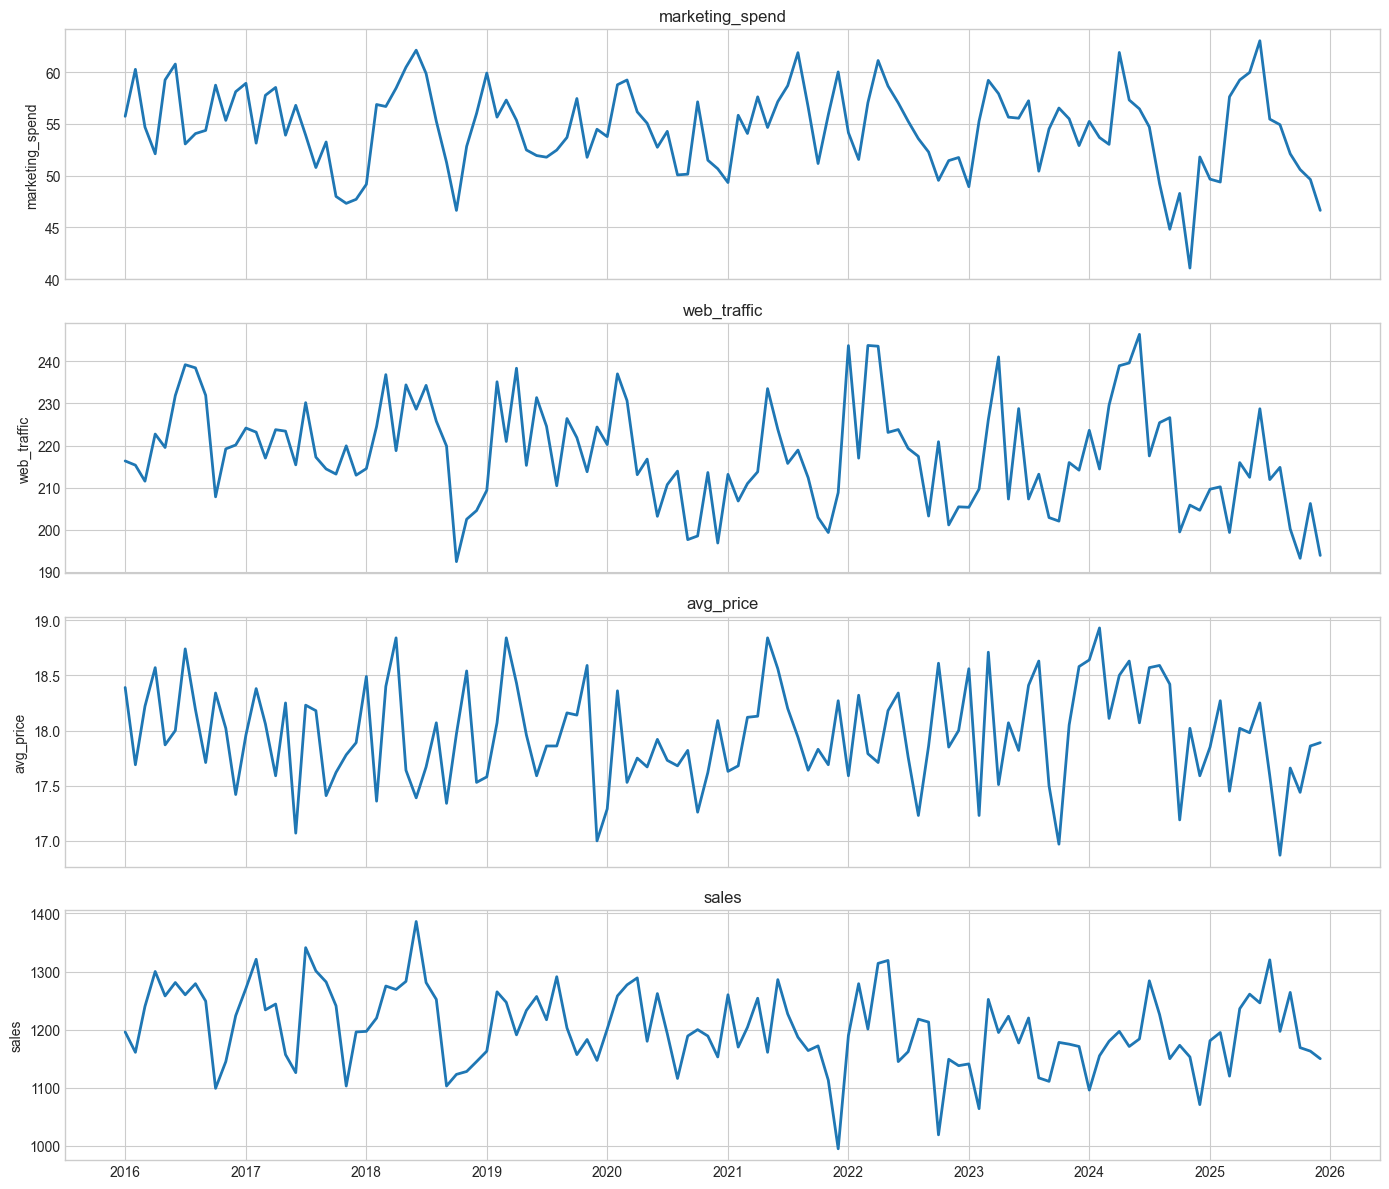

In [3]:
ts = df.set_index('date')

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
for ax, col in zip(axes, ts.columns):
    ax.plot(ts.index, ts[col], linewidth=2)
    ax.set_title(col)
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()


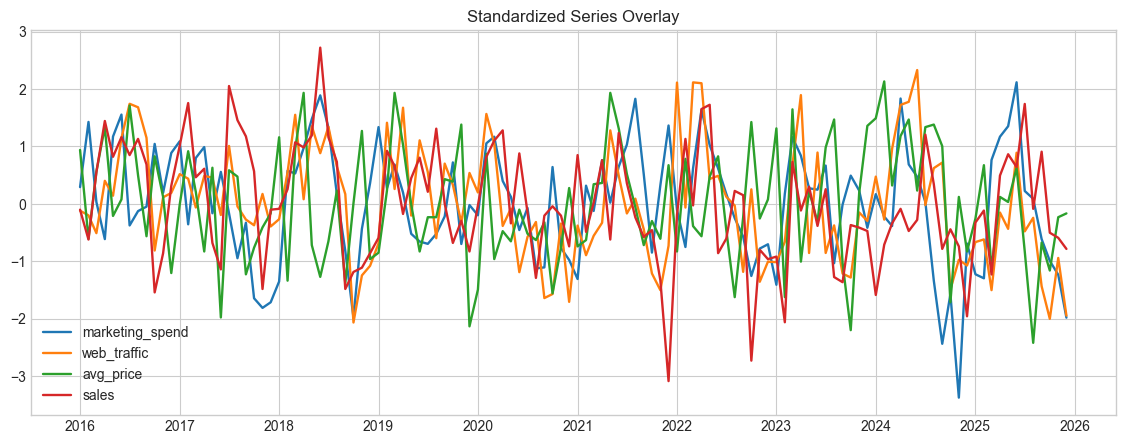

In [4]:
# Standardized overlay plot for easier visual comparison
z = (ts - ts.mean()) / ts.std()

plt.figure(figsize=(14, 5))
for col in z.columns:
    plt.plot(z.index, z[col], label=col, linewidth=1.7)
plt.title('Standardized Series Overlay')
plt.legend()
plt.show()


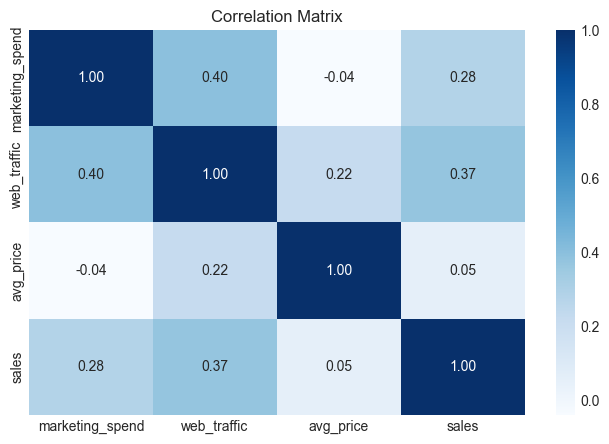

In [5]:
plt.figure(figsize=(8, 5))
sns.heatmap(ts.corr(), annot=True, cmap='Blues', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()


## 3) Stationarity Check (ADF)

VAR typically requires stationary inputs. We test each variable:
- if all p-values < 0.05: fit VAR on levels
- else: fit VAR on first differences


In [6]:
def adf_pvalue(x):
    return adfuller(x.dropna())[1]

adf_table = pd.DataFrame({
    'variable': ts.columns,
    'adf_pvalue': [adf_pvalue(ts[c]) for c in ts.columns]
})

adf_table


,variable,adf_pvalue
0,marketing_spend,1.926577e-07
1,web_traffic,5.837053e-06
2,avg_price,4.336172e-17
3,sales,3.335005e-01


In [7]:
need_diff = (adf_table['adf_pvalue'] >= 0.05).any()

if need_diff:
    model_data = ts.diff().dropna()
    data_note = 'Using first differences (at least one non-stationary variable).'
else:
    model_data = ts.copy()
    data_note = 'Using levels (all variables stationary).'

print(data_note)
print('Model data shape:', model_data.shape)
model_data.head()


Using first differences (at least one non-stationary variable).
Model data shape: (119, 4)


,marketing_spend,web_traffic,avg_price,sales
date,,,,
2016-02-01,4.54,-1.00,-0.70,-35.0
2016-03-01,-5.58,-3.81,0.53,79.0
2016-04-01,-2.58,11.21,0.35,60.0
2016-05-01,7.14,-3.20,-0.70,-42.0
2016-06-01,1.53,12.36,0.13,23.0


## 4) Lag Order Selection

We compare candidate lag lengths up to 8 months and choose by AIC.


In [8]:
selector = VAR(model_data).select_order(maxlags=8)
print(selector.summary())

selected_lag = selector.aic if selector.aic is not None else 1
selected_lag = int(selected_lag)
print('Selected lag by AIC:', selected_lag)


 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0       15.47       15.57   5.246e+06       15.51
1       14.65      15.14*   2.301e+06       14.85
2       14.45       15.33   1.896e+06      14.81*
3       14.52       15.79   2.038e+06       15.04
4       14.56       16.22   2.121e+06       15.23
5       14.52       16.57   2.058e+06       15.35
6      14.30*       16.74  1.678e+06*       15.29
7       14.40       17.24   1.892e+06       15.55
8       14.57       17.80   2.297e+06       15.88
-------------------------------------------------
Selected lag by AIC: 6


/opt/anaconda3/envs/mldl-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


## 5) Fit VAR Model


In [9]:
var_model = VAR(model_data)
var_res = var_model.fit(selected_lag)

print(var_res.summary())


  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sat, 21, Mar, 2026
Time:                     13:39:49
--------------------------------------------------------------------
No. of Equations:         4.00000    BIC:                    16.6945
Nobs:                     113.000    HQIC:                   15.2604
Log likelihood:          -1348.23    FPE:                1.64079e+06
AIC:                      14.2809    Det(Omega_mle):         737649.
--------------------------------------------------------------------
Results for equation marketing_spend
                        coefficient       std. error           t-stat            prob
-------------------------------------------------------------------------------------
const                     -0.023058         0.325050           -0.071           0.943
L1.marketing_spend        -0.342715         0.103674           -3.306           0.001
L1.web_traffic            -0.0

/opt/anaconda3/envs/mldl-env/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [10]:
print('Model stability check:', var_res.is_stable(verbose=False))
print('Inverse roots (all should be > 1 in modulus for stability):')
print(np.round(var_res.roots, 3))


Model stability check: True
Inverse roots (all should be > 1 in modulus for stability):
[-2.677-0.j    -0.808+1.901j -0.808-1.901j -1.979-0.j     0.81 -1.268j
  0.81 +1.268j -1.013+0.743j -1.013-0.743j -1.172+0.378j -1.172-0.378j
  0.756-0.957j  0.756+0.957j -0.299-1.176j -0.299+1.176j -0.034+1.204j
 -0.034-1.204j  0.638+0.997j  0.638-0.997j -0.416-1.106j -0.416+1.106j
 -0.97 -0.638j -0.97 +0.638j  0.903+0.625j  0.903-0.625j]


## 6) Residual Diagnostics


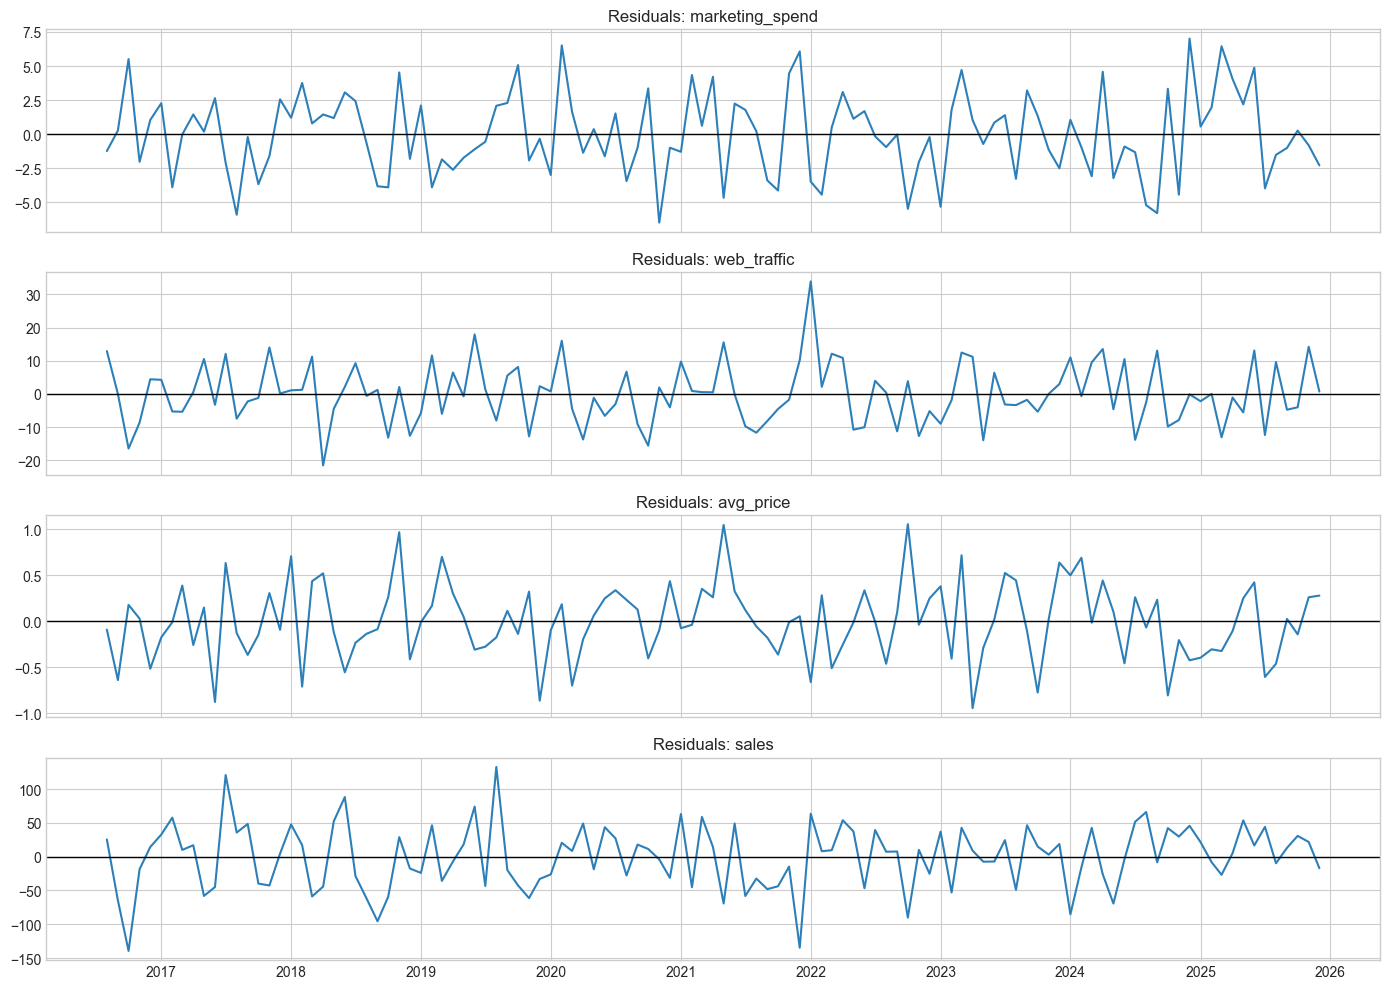

In [11]:
resid = var_res.resid

fig, axes = plt.subplots(resid.shape[1], 1, figsize=(14, 10), sharex=True)
for ax, col in zip(axes, resid.columns):
    ax.plot(resid.index, resid[col], color='#2c7fb8')
    ax.axhline(0, color='black', linewidth=1)
    ax.set_title(f'Residuals: {col}')

plt.tight_layout()
plt.show()


In [13]:
print('Whiteness (Portmanteau) test:')
print(var_res.test_whiteness(nlags=12))

print('Normality test:')
print(var_res.test_normality())

Whiteness (Portmanteau) test:
<statsmodels.tsa.vector_ar.hypothesis_test_results.WhitenessTestResults object. H_0: residual autocorrelation up to lag 12 is zero: reject at 5% significance level. Test statistic: 124.804, critical value: 119.871>, p-value: 0.026>
Normality test:
<statsmodels.tsa.vector_ar.hypothesis_test_results.NormalityTestResults object. H_0: data generated by normally-distributed process: fail to reject at 5% significance level. Test statistic: 7.968, critical value: 15.507>, p-value: 0.437>


## 7) Granger Causality Toward Sales


In [14]:
causality_summary = []
for cause in ['marketing_spend', 'web_traffic', 'avg_price']:
    test = var_res.test_causality('sales', [cause], kind='f')
    causality_summary.append({'cause': cause, 'pvalue': test.pvalue})
    print(f'{cause} -> sales | p-value = {test.pvalue:.5f}')

causality_df = pd.DataFrame(causality_summary)
causality_df


marketing_spend -> sales | p-value = 0.02894
web_traffic -> sales | p-value = 0.00004
avg_price -> sales | p-value = 0.16015


,cause,pvalue
0,marketing_spend,0.028939
1,web_traffic,0.000044
2,avg_price,0.160154


## 8) Impulse Response Functions (IRF)

IRF visualizes dynamic response of variables to one-time shocks.


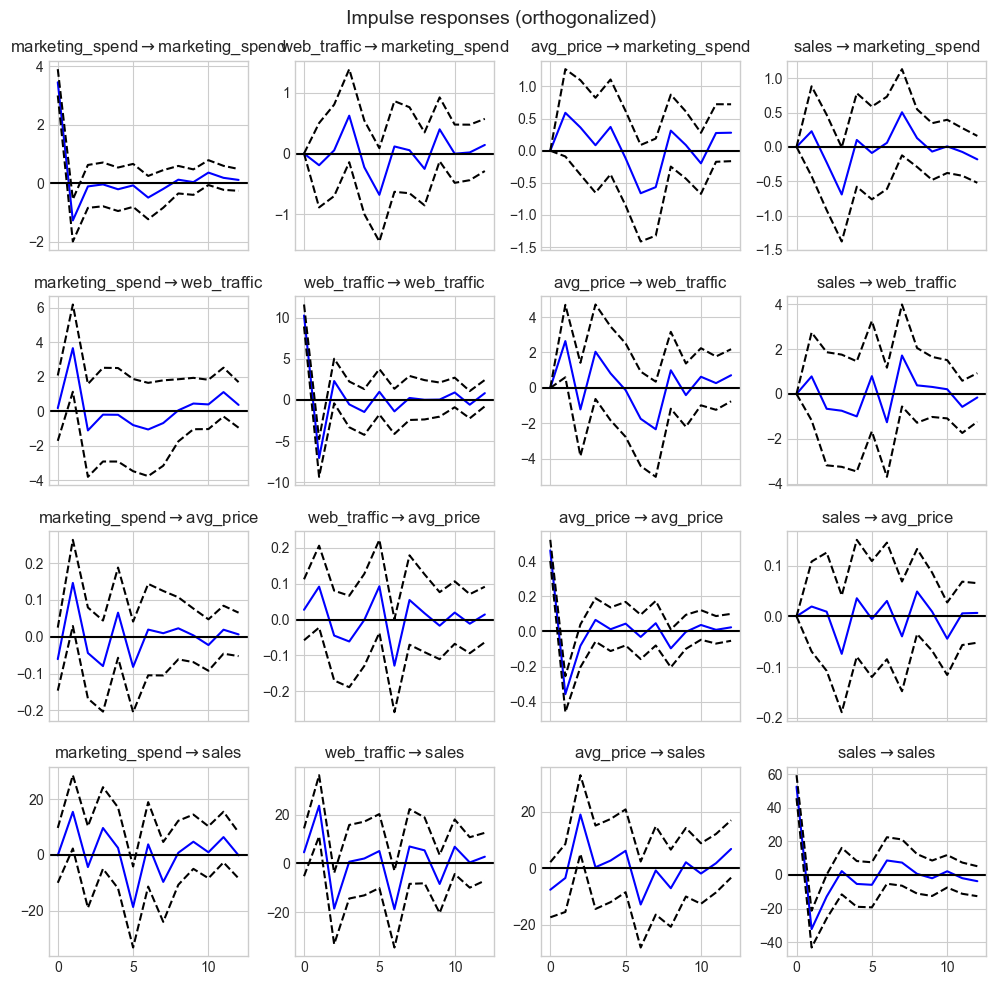

In [15]:
irf = var_res.irf(12)
irf.plot(orth=True)
plt.tight_layout()
plt.show()


## 9) Forecast Error Variance Decomposition (FEVD)

FEVD shows how much forecast uncertainty in each variable is explained by shocks from each variable.


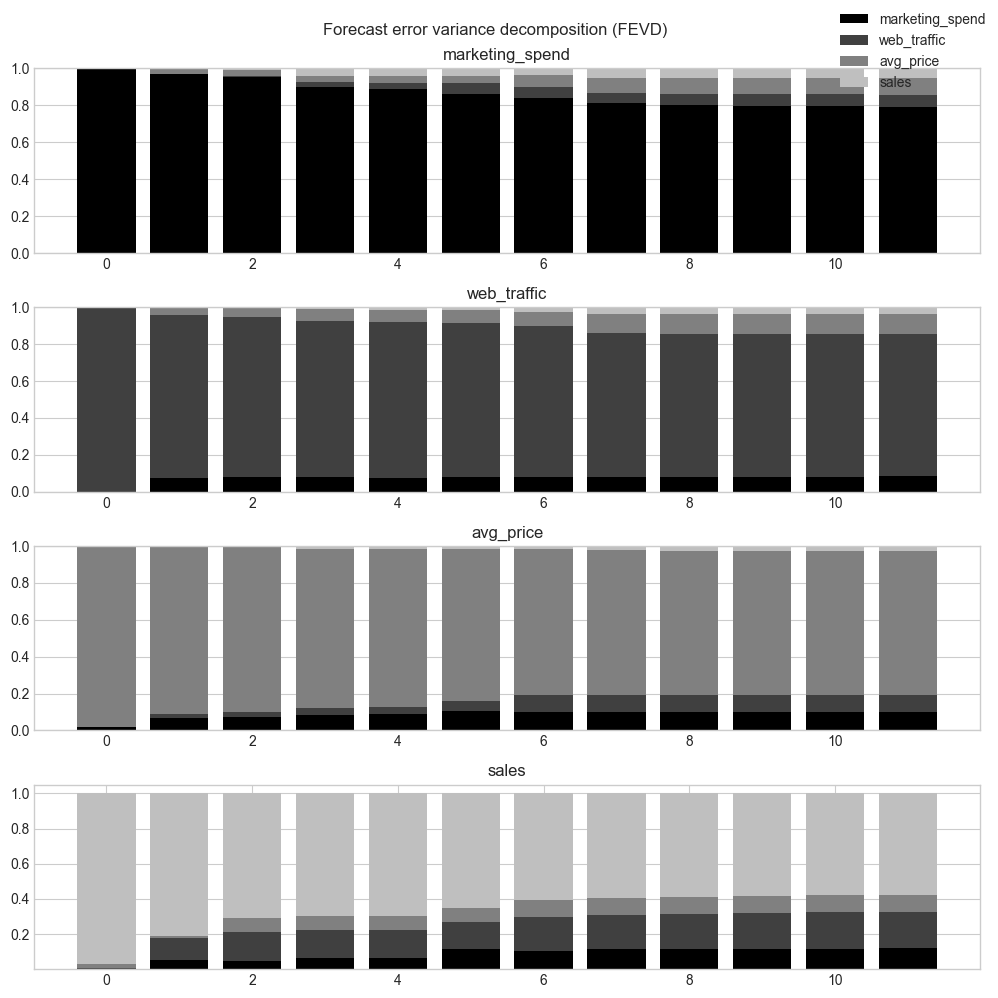

In [16]:
fevd = var_res.fevd(12)
fevd.plot()
plt.tight_layout()
plt.show()


## 10) Forecast Next 12 Months


In [17]:
steps = 12
history = model_data.values[-selected_lag:]

mean_fc, lower_fc, upper_fc = var_res.forecast_interval(history, steps=steps, alpha=0.05)
future_idx = pd.date_range(start=model_data.index[-1] + pd.offsets.MonthBegin(1), periods=steps, freq='MS')

mean_df = pd.DataFrame(mean_fc, index=future_idx, columns=model_data.columns)
lower_df = pd.DataFrame(lower_fc, index=future_idx, columns=[f'{c}_lower' for c in model_data.columns])
upper_df = pd.DataFrame(upper_fc, index=future_idx, columns=[f'{c}_upper' for c in model_data.columns])

forecast_df = pd.concat([mean_df, lower_df, upper_df], axis=1)
forecast_df.head()


,marketing_spend,web_traffic,avg_price,sales,marketing_spend_lower,web_traffic_lower,avg_price_lower,sales_lower,marketing_spend_upper,web_traffic_upper,avg_price_upper,sales_upper
2026-01-01,2.805142,4.817795,-0.031420,15.074499,-3.945377,-15.315690,-0.944919,-89.543921,9.555660,24.951279,0.882078,119.692919
2026-02-01,4.038352,12.821941,-0.345842,40.734595,-3.270023,-13.203145,-1.546255,-93.695107,11.346727,38.847027,0.854571,175.164297
2026-03-01,2.016182,0.636461,0.141481,4.500512,-5.343635,-26.003946,-1.075918,-142.079149,9.375999,27.276867,1.358880,151.080173
2026-04-01,-1.295364,6.228667,0.340983,59.254861,-8.880809,-20.774588,-0.907301,-88.613544,6.290082,33.231923,1.589267,207.123266
2026-05-01,0.308237,-3.775020,-0.242915,-27.642199,-7.337645,-31.051712,-1.499966,-176.109127,7.954119,23.501673,1.014135,120.824728


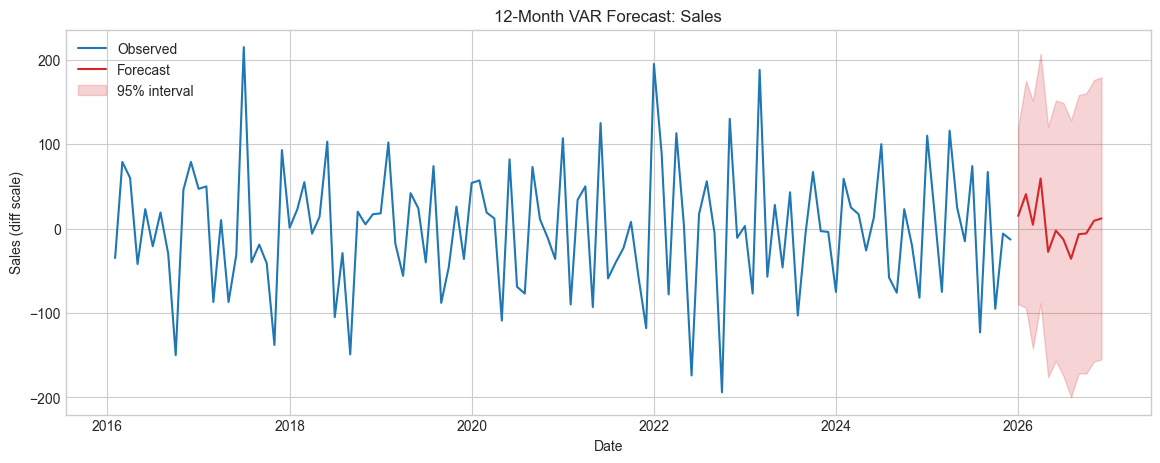

In [18]:
# Plot sales forecast
col = 'sales'
plt.figure(figsize=(14, 5))
plt.plot(model_data.index, model_data[col], label='Observed', color='#1f77b4')
plt.plot(mean_df.index, mean_df[col], label='Forecast', color='#d62728')
plt.fill_between(
    mean_df.index,
    lower_df[f'{col}_lower'],
    upper_df[f'{col}_upper'],
    color='#d62728', alpha=0.2, label='95% interval'
)
plt.title('12-Month VAR Forecast: Sales')
plt.xlabel('Date')
plt.ylabel('Sales' if not need_diff else 'Sales (diff scale)')
plt.legend()
plt.show()


## 11) Compact Interpretation (Auto-generated)


In [19]:
sig = causality_df[causality_df['pvalue'] < 0.05]['cause'].tolist()
non_sig = causality_df[causality_df['pvalue'] >= 0.05]['cause'].tolist()

print('Model summary for report:')
print(f'- Data used: {"first differences" if need_diff else "levels"}')
print(f'- Selected VAR lag: {selected_lag}')
print(f'- Stability: {var_res.is_stable(verbose=False)}')

if sig:
    print(f'- Significant Granger causes of sales (5%): {", ".join(sig)}')
if non_sig:
    print(f'- Not significant at 5%: {", ".join(non_sig)}')

print('- Use IRF plots to describe shock direction and persistence (0-12 months).')
print('- Use FEVD to state which variables dominate sales forecast variance over horizon.')


Model summary for report:
- Data used: first differences
- Selected VAR lag: 6
- Stability: True
- Significant Granger causes of sales (5%): marketing_spend, web_traffic
- Not significant at 5%: avg_price
- Use IRF plots to describe shock direction and persistence (0-12 months).
- Use FEVD to state which variables dominate sales forecast variance over horizon.
